## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1** 

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3** 
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:
+ Используйте groupby и nunique() для подсчёта количества клиентов.
+ Для объединения датафреймов — merge.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [3]:
# Задача 1
df_indiv_70 = df.groupby(['id_user', 'city', 'gender', 'age']).agg({'mon':'count', 
                                                                   'cnt_indiv':'sum', 
                                                                   'cnt_total':'sum', 
                                                                   'sum_total':'sum'}).reset_index().rename(columns={'mon':'nmonths'})

df_indiv_70['share_indiv'] = df_indiv_70['cnt_indiv']/df_indiv_70['cnt_total']*100 # расчитываем долю индивилуальных тренировок 
df_indiv_70 = df_indiv_70[df_indiv_70['share_indiv']>70] # оставляем пользователей у которых более 70% индивидуальных тренировок 

df_indiv_70['avg_check'] = df_indiv_70['sum_total']/df_indiv_70['cnt_total'] # определяем средний чек
df_indiv_70['avg_train_per_mon'] = df_indiv_70['cnt_total']/df_indiv_70['nmonths'] # среднее количество тренировок в месяц

df_indiv_70.head()

,id_user,city,gender,age,nmonths,cnt_indiv,cnt_total,sum_total,share_indiv,avg_check,avg_train_per_mon
0,1000,СПб,female,44.0,9,33,33,58600,100.0,1775.757576,3.666667
3,1004,Екатеринбург,male,60.0,9,18,18,32000,100.0,1777.777778,2.000000
4,1005,СПб,female,35.0,2,7,7,12600,100.0,1800.000000,3.500000
6,1007,Москва,female,58.0,4,5,5,9000,100.0,1800.000000,1.250000
8,1009,Москва,female,22.0,4,9,9,16200,100.0,1800.000000,2.250000


In [4]:
# сгруппируем данные по городам и полу
df_indiv_70_gr = df_indiv_70.groupby(['city', 'gender']).agg({'id_user':'nunique',
                                                             'avg_check':'mean',
                                                             'avg_train_per_mon':'mean'}).\
    rename(columns = {'id_user':'nuser'}).sort_values('nuser', ascending = False).reset_index()

df_indiv_70_gr 

,city,gender,nuser,avg_check,avg_train_per_mon
0,Москва,female,118,1777.346427,3.141311
1,Москва,male,59,1787.065715,3.872733
2,СПб,female,32,1793.323478,3.399777
3,СПб,male,28,1778.201734,2.821443
4,Екатеринбург,male,12,1789.811240,3.256184
5,Казань,male,12,1786.111642,2.931548
6,Екатеринбург,female,12,1790.801657,3.009524
7,Казань,female,8,1732.600733,3.756250


In [5]:
df_indiv_70['city'].value_counts() # локационная зависимость

city
Москва          177
СПб              60
Екатеринбург     24
Казань           20
Name: count, dtype: int64

In [6]:
df_indiv_70['gender'].value_counts() # гендерная зависимость 

gender
female    170
male      111
Name: count, dtype: int64

In [7]:
avg_check_total = df['sum_total'].sum()/df['cnt_total'].sum() # средний чек по всем пользователям
print(avg_check_total) 

1058.2785376117833


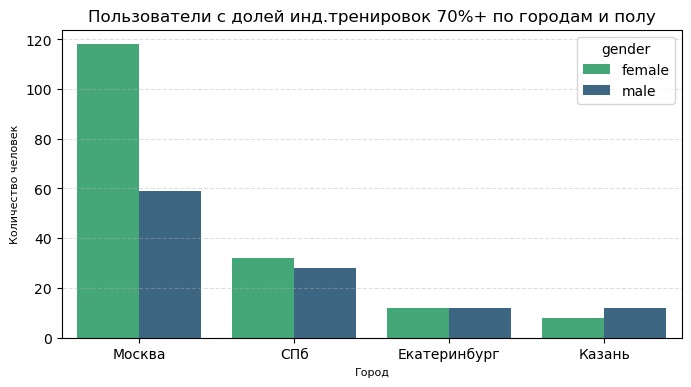

In [8]:
# Визуализация количества пользователей с 70%+ инд.тренировок по городам и полу
plt.figure(figsize=(8, 4))
sns.barplot(data = df_indiv_70_gr, x = 'city', y = 'nuser', hue = 'gender', palette = 'viridis_r')
plt.title('Пользователи с долей инд.тренировок 70%+ по городам и полу')
plt.xlabel('Город', fontsize=8)
plt.ylabel('Количество человек', fontsize=8)
plt.grid(axis = 'y', linestyle='--', alpha = 0.4)

plt.show()

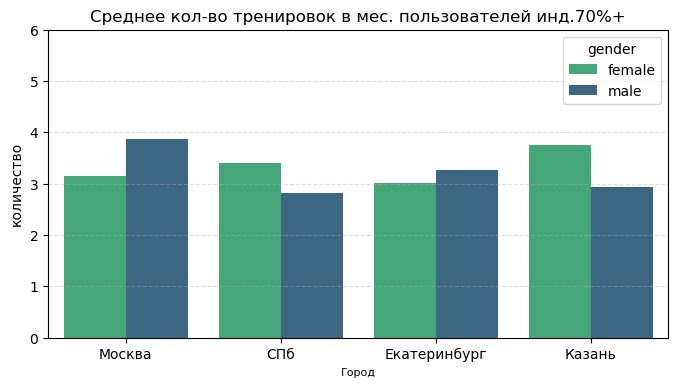

In [9]:
# Визуализация среднего количества тренировок пользователей с 70%+ инд.тренировок по городам и полу
plt.figure(figsize=(8, 4))
sns.barplot(data = df_indiv_70_gr, x = 'city', y = 'avg_train_per_mon', hue = 'gender', palette = 'viridis_r')
plt.title('Cреднее кол-во тренировок в мес. пользователей инд.70%+')
plt.xlabel('Город', fontsize=8)
plt.ylabel('количество')
plt.ylim(0, 6)
plt.grid(axis = 'y', linestyle='--', alpha = 0.4)

plt.show()

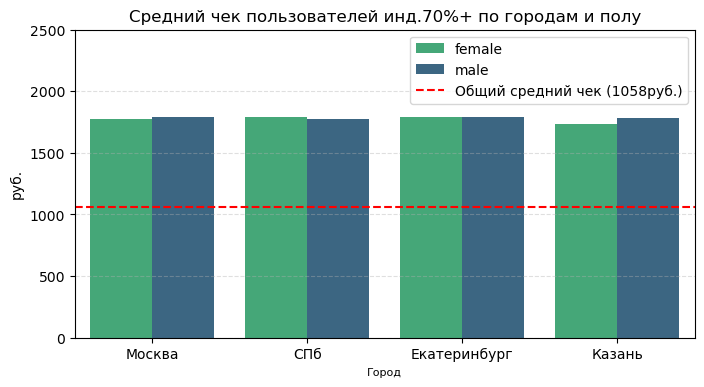

In [10]:
# Визуализация среднего чека пользователей с 70%+ инд.тренировок по городам и полу
plt.figure(figsize=(8, 4))
sns.barplot(data = df_indiv_70_gr, x = 'city', y = 'avg_check', hue = 'gender', palette = 'viridis_r')
plt.title('Cредний чек пользователей инд.70%+ по городам и полу')
plt.xlabel('Город', fontsize=8)
plt.ylabel('руб.')
plt.ylim(0, 2500)
plt.axhline(y=1058, color='red', linestyle='--', label = 'Общий средний чек (1058руб.)') # Линию среднего чека по всей базе пользователей
plt.legend()
plt.grid(axis = 'y', linestyle='--', alpha = 0.4)

plt.show()

In [11]:
# Анализ:
# Индивидуальные тренировки чаще выбирают женщины из Москвы, посещая зал примерно 3 раза в месяц.
# Да, зависимость от города наблюдается довольно четко: в Москве людей, выбирающих индивидуальный формат тренировок находится в разы больше чем в других городах.
# В целом индивидуальными тренировками чаще пользуются женщины. В Москве и СПб данное соотношение подтверждается. Однако в Екатеринбурге - гендер не влияет, а в Казани индивидуальных тренировок больше у мужчин.
# Средний чек нашей группы пользователей гораздо выше среднего чека по всей базе (1058 руб.) и находится на уровне примерно 1732-1793 руб., т.е. пользователи, чаще выбирающие индивидуальные тренировки - более высокодоходны.

### Задача 2. Топ-10 клиентов

In [12]:
# Задача 2.
# Определяем 10 самых активных пользователей 
df_top_10 = df.groupby('id_user').agg(cnt_train = ('cnt_total', 'sum')).sort_values('cnt_train', ascending = False).reset_index().head(10)

df_top_10

,id_user,cnt_train
0,1381,159
1,1013,151
2,1657,144
3,1506,138
4,1929,130
5,1001,129
6,1570,129
7,1002,128
8,1194,127
9,1582,127


In [13]:
lst_top_10 = df_top_10['id_user'].tolist() # сохраняем их идентификаторы в список
lst_top_10

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1194, 1582]

In [14]:
df_top = df[df['id_user'].isin(lst_top_10)]
df_top.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female
11,1001,2023-03,8,6,6400,10800,14,17200,2023-01,2023-12,Москва,35.0,female
12,1001,2023-04,9,5,7200,9000,14,16200,2023-01,2023-12,Москва,35.0,female
13,1001,2023-05,3,7,2400,11200,10,13600,2023-01,2023-12,Москва,35.0,female


In [15]:
# Построим распределение этих пользователей по городу и полу
df_top_gr = df_top.groupby(['city', 'gender']).agg(nuser_top = ('id_user', 'nunique')).sort_values('nuser_top', ascending = False).reset_index()
df_top_gr 

,city,gender,nuser_top
0,Москва,female,3
1,Москва,male,3
2,Екатеринбург,male,2
3,СПб,female,1
4,СПб,male,1


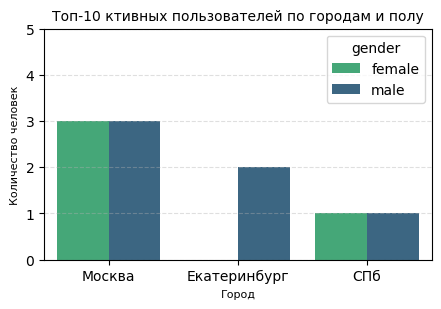

In [16]:
# Визуализация распределения активных пользователей  по городам и полу
plt.figure(figsize=(5, 3))
sns.barplot(data = df_top_gr, x = 'city', y = 'nuser_top', hue = 'gender', palette = 'viridis_r')
plt.title('Топ-10 ктивных пользователей по городам и полу', fontsize=10)
plt.xlabel('Город', fontsize=8)
plt.ylabel('Количество человек', fontsize=8)
plt.ylim(0, 5)
plt.grid(axis = 'y', linestyle='--', alpha = 0.4)

plt.show()

In [17]:
# Преобразуем таблицу df_top_gr 
pivot_top = df_top_gr.pivot(index ='city', 
                            columns = 'gender',
                            values = 'nuser_top').fillna(0)
order = ['Москва', 'Екатеринбург', 'СПб']
pivot_top = pivot_top.reindex(order)
pivot_top

gender,female,male
city,,
Москва,3.0,3.0
Екатеринбург,0.0,2.0
СПб,1.0,1.0


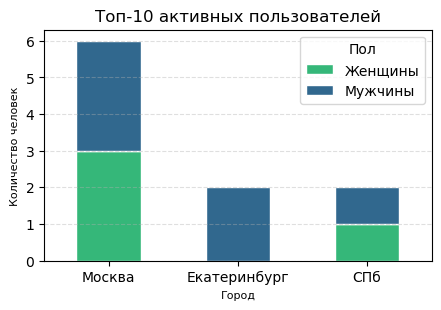

In [18]:
# Построим барчарт с накоплениями 
colors = sns.color_palette('viridis_r', 2)
ax = pivot_top.plot(kind = 'bar',
                   stacked = True,
                   figsize = (5, 3),
                   color = colors, 
                   edgecolor = 'white',
                   linewidth = 1,
                   rot = 0)
plt.title('Топ-10 активных пользователей', fontsize=12)
plt.xlabel('Город',fontsize=8)
plt.ylabel('Количество человек',fontsize=8)
plt.legend(title = 'Пол', labels = ['Женщины', 'Мужчины'])
plt.grid(axis = 'y', linestyle='--', alpha = 0.4)

plt.show()

In [19]:
# Анализ:
# Больше всего супер-активных клиентов находится в Москве. 
# Из 10 самых активных пользователей 6 человек - это мужчины, при этом: в Москве и СПБ - мужчин и женщин 50/50, в Екатеринбурге активные - это мужчины.

### Задача 3. Динамика клиентской базы

In [20]:
# Задача 3.  Создаем датафрейм с новыми клиентами по месяцам
new_clients = df.groupby('min_mon')['id_user'].nunique().reset_index()
new_clients.columns = ['month', 'new_clients']
new_clients.head()

,month,new_clients
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57


In [21]:
# Создаем датафрейм с ушедшими клиентами по месяцам
gone_clients = df.groupby('max_mon')['id_user'].nunique().reset_index()
gone_clients.columns = ['month', 'gone_clients']
gone_clients.head()

,month,gone_clients
0,2023-01,15
1,2023-02,22
2,2023-03,37
3,2023-04,21
4,2023-05,21


In [22]:
# Создаем датафрейм с активными клиентами по месяцам
active_clients = df.groupby('mon')['id_user'].nunique().reset_index()
active_clients.columns = ['month', 'active_clients']
active_clients.head()

,month,active_clients
0,2023-01,337
1,2023-02,350
2,2023-03,355
3,2023-04,345
4,2023-05,360


In [23]:
# Объединяем в один датафрейм 
df_combi = active_clients.merge(new_clients, on='month').merge(gone_clients, on='month')
df_combi

,month,active_clients,new_clients,gone_clients
0,2023-01,337,337,15
1,2023-02,350,88,22
2,2023-03,355,83,37
3,2023-04,345,62,21
4,2023-05,360,57,21
5,2023-06,383,51,13
6,2023-07,412,48,33
7,2023-08,423,35,33
8,2023-09,429,28,55
9,2023-10,441,27,101


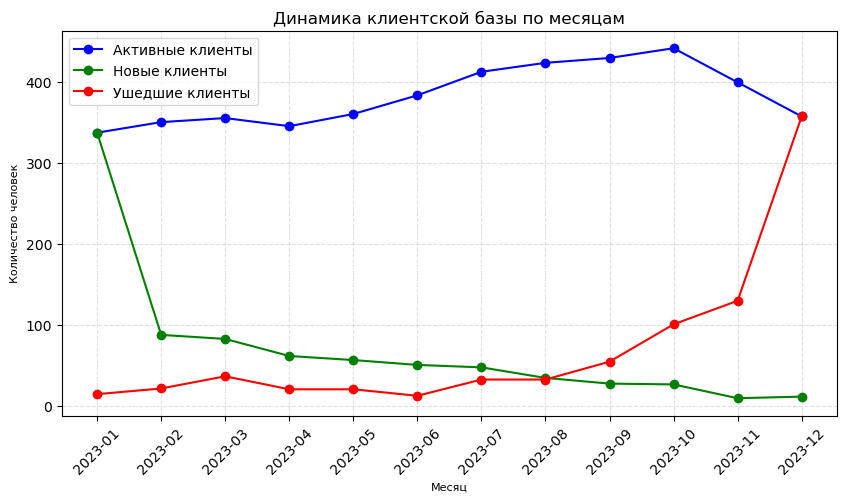

In [24]:
# Строим линейный график
plt.figure(figsize=(10, 5))
plt.plot(active_clients['month'], active_clients['active_clients'], label = 'Активные клиенты', marker = 'o', color = 'blue') # Активные клиенты
plt.plot(new_clients['month'], new_clients['new_clients'], label = 'Новые клиенты', marker = 'o', color = 'green') # Новые клиенты
plt.plot(gone_clients['month'], gone_clients['gone_clients'], label = 'Ушедшие клиенты', marker = 'o', color = 'red') # Ушедшие клиенты

plt.title('Динамика клиентской базы по месяцам', fontsize=12)
plt.xlabel('Месяц',fontsize=8)
plt.ylabel('Количество человек',fontsize=8)
plt.xticks(rotation=45)
plt.legend()
plt.grid(linestyle='--', alpha = 0.4)

plt.show()